<a href="https://colab.research.google.com/github/kenichiy19/1CCPK-SERS/blob/main/Checkpoint/2026_2/Checkpoint%201/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes**
Felipe Pereira Restivo - RM: 570712

Gabriel Rodrigues Zappelloni - RM: 572060

Kenichi Caio Yamamoto - RM: 569815

Maykon de Lima Silva – RM: 574022

Rodger Costa Rios - RM: 571438

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético `precisa analisar o comportamento da carga elétrica de uma região` atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam `data/hora, área de carga e valor de carga`.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1
dados = pd.DataFrame(registros)
dados.head()
print(f'Quantidade de linhas: {dados.shape[0]}')
print(f'Quantidade de colunas: {dados.shape[1]}')
print(dados.columns.tolist())
dados.info()
display(dados.describe(include="all"))



Quantidade de linhas: 336
Quantidade de colunas: 11
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2

dados.rename(columns={'cod_areacarga': 'regiao', # regiao
                      'dat_referencia': 'data', # data
                      'din_referenciautc': 'data_hora', # data/hora
                      'val_cargaglobal': 'carga_mw', # carga consumida total
                      'val_cargammgd': 'microgeracao_solar', # energia gerada por moradores (painel solar)
}, inplace=True)

colunas = ['regiao', 'data', 'data_hora', 'carga_mw', 'microgeracao_solar']
df_analise = dados[colunas].copy()

print("--- Valores Ausentes ---")
print(df_analise.isnull().sum())

print("\n--- Tipos de Dados Originais ---")
print(df_analise.dtypes)

df_analise['carga_mw'] = pd.to_numeric(df_analise['carga_mw'], errors='coerce')
df_analise['microgeracao_solar'] = pd.to_numeric(df_analise['microgeracao_solar'], errors='coerce')
df_analise['data'] = pd.to_datetime(df_analise['data'])
df_analise['data_hora'] = pd.to_datetime(df_analise['data_hora'])

df_analise.head()

--- Valores Ausentes ---
regiao                0
data                  0
data_hora             0
carga_mw              0
microgeracao_solar    0
dtype: int64

--- Tipos de Dados Originais ---
regiao                 object
data                   object
data_hora              object
carga_mw              float64
microgeracao_solar    float64
dtype: object


,regiao,data,data_hora,carga_mw,microgeracao_solar
0,SP,2025-08-01,2025-08-01 03:30:00+00:00,15913.618,21.13
1,SP,2025-08-01,2025-08-01 04:00:00+00:00,15251.414,21.13
2,SP,2025-08-01,2025-08-01 04:30:00+00:00,14606.733,21.13
3,SP,2025-08-01,2025-08-01 05:00:00+00:00,14182.290,21.13
4,SP,2025-08-01,2025-08-01 05:30:00+00:00,13838.488,21.13


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

minimo = df_analise['carga_mw'].min()
maximo = df_analise['carga_mw'].max()
media = df_analise['carga_mw'].mean()
mediana = df_analise['carga_mw'].median()
amplitude = maximo - minimo
quantidade_total = len(df_analise)

print(f"Carga Mínima: {minimo:.2f} MW")
print(f"Carga Máxima: {maximo:.2f} MW")
print(f"Carga Média: {media:.2f} MW")
print(f"Mediana: {mediana:.2f} MW")
print(f"Amplitude: {amplitude:.2f} MW")
print(f"Quantidade total de medições: {quantidade_total}")

Carga Mínima: 12139.25 MW
Carga Máxima: 23185.31 MW
Carga Média: 17870.83 MW
Mediana: 18199.13 MW
Amplitude: 11046.06 MW
Quantidade total de medições: 336


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4

limiar_90 = 0.90 * maximo
df_alta_demanda = df_analise[df_analise['carga_mw'] > limiar_90]
registros_limiar = len(df_alta_demanda)
percentual_limiar = (registros_limiar / quantidade_total) * 100
linha_pico = df_alta_demanda[df_alta_demanda['carga_mw'] == maximo]

print(f"Limiar de alta demanda: {limiar_90:.2f} MW")
print(f"Registros em alta demanda: {registros_limiar}")
print(f"Percentual do tempo em pico: {percentual_limiar:.2f}%")
print("\n")
display(linha_pico)
print("\n")
df_alta_demanda.head()

Limiar de alta demanda: 20866.78 MW
Registros em alta demanda: 50
Percentual do tempo em pico: 14.88%




,regiao,data,data_hora,carga_mw,microgeracao_solar
37,SP,2025-08-01,2025-08-01 22:00:00+00:00,23185.312,21.13


,regiao,data,data_hora,carga_mw,microgeracao_solar
35,SP,2025-08-01,2025-08-01 21:00:00+00:00,21088.959,133.8406
36,SP,2025-08-01,2025-08-01 21:30:00+00:00,22398.360,21.2638
37,SP,2025-08-01,2025-08-01 22:00:00+00:00,23185.312,21.1300
38,SP,2025-08-01,2025-08-01 22:30:00+00:00,22903.314,21.1300
39,SP,2025-08-01,2025-08-01 23:00:00+00:00,22358.701,21.1300


Os períodos próximos ao pico representam uma pequena parcela do período analisado. Isto é provado ao calcular o percentual, obtendo um resultado de 14,88%.

Isso demonstra que o consumo extremo não é constante. O estresse máximo ocorre de forma aguda e concentrada em poucas horas específicas, como o pico registrado às 22:00. Enquanto na maior parte do dia - cerca de 85% do tempo - a demanda permanece em níveis confortáveis e mais baixos.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

**Critério definido pela equipe**: carga acima da média.

**Justificativa**: Verificar quanto tempo o sistema opera acima do seu padrão normal de consumo.

In [ ]:
# Desenvolva aqui o DESAFIO 5

df_acima_media = df_analise[df_analise['carga_mw'] > media]
qtd_acima_media = len(df_acima_media)
percentual_acima = (qtd_acima_media / quantidade_total) * 100

display(df_acima_media)
print(f'Quantidade de registros: {qtd_acima_media}')
print(f'Percentual: {percentual_acima:.2f}%')

,regiao,data,data_hora,carga_mw,microgeracao_solar
15,SP,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,680.4232
16,SP,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,1219.7958
17,SP,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,1727.5842
18,SP,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,2206.0276
19,SP,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,2635.2324
...,...,...,...,...,...
330,SP,2025-08-07,2025-08-08 00:30:00+00:00,21716.170,21.1300
331,SP,2025-08-07,2025-08-08 01:00:00+00:00,20930.443,21.1300
332,SP,2025-08-07,2025-08-08 01:30:00+00:00,19936.190,21.1300
333,SP,2025-08-07,2025-08-08 02:00:00+00:00,19153.877,21.1300


Quantidade de registros: 184
Percentual: 54.76%


**5. Comparação: Acima da Média vs. Alta Demanda**

* **Operação Padrão (Acima da Média):** O sistema elétrico de São Paulo operou acima da sua carga média (17.870 MW) durante **54,76%** do tempo analisado (184 medições).
* **Operação de Risco (Alta Demanda):** Em contrapartida, os episódios de estresse da rede, onde a carga ultrapassa 90% do limite máximo, representaram apenas **14,88%** do tempo (50 medições).
* **Conclusão Técnica:** O sistema possui uma operação majoritariamente concentrada em níveis intermediários e altos, suprindo a rotina diária sem grandes problemas operacionais. Os dados provam que o consumo não pressiona o limite extremo da rede de forma contínua, restringindo os cenários de alta demanda a eventos pontuais e de curta duração.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

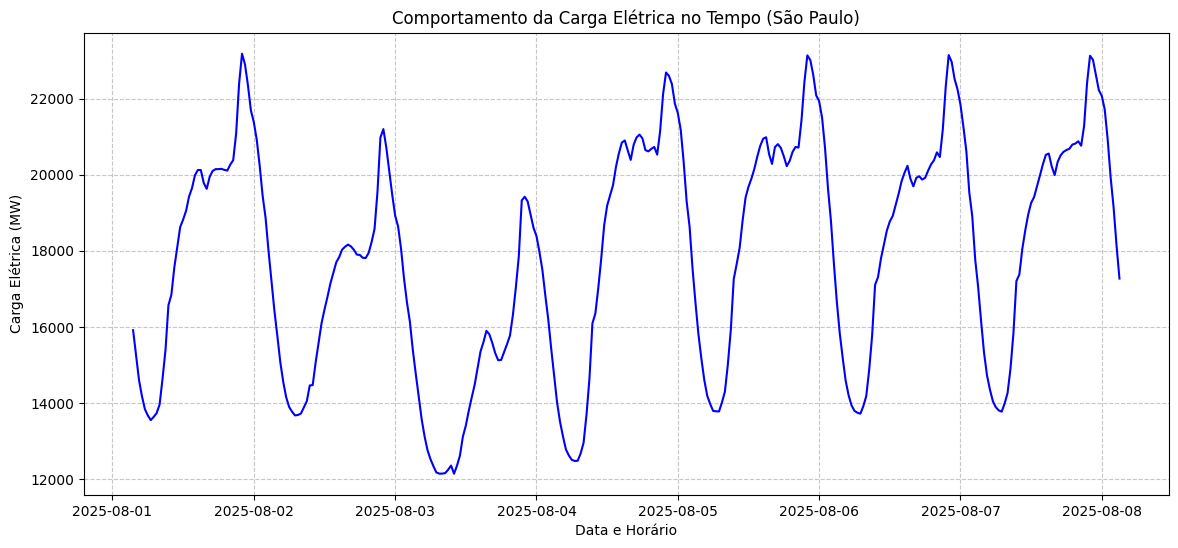

In [ ]:
# Desenvolva aqui o DESAFIO 6

plt.figure(figsize=(14, 6))
plt.plot(df_analise['data_hora'], df_analise['carga_mw'], color='blue', linewidth=1.5)
plt.title("Comportamento da Carga Elétrica no Tempo (São Paulo)")
plt.xlabel("Data e Horário")
plt.ylabel("Carga Elétrica (MW)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

O gráfico demonstra uma clara sazonalidade diária (comportamento cíclico). Observa-se a formação de "vales" profundos durante as madrugadas, momento de menor demanda, seguidos por uma elevação contínua durante o horário comercial. Os picos de consumo (cristas das ondas) concentram-se consistentemente no início da noite, momento em que a iluminação pública e residencial é acionada.

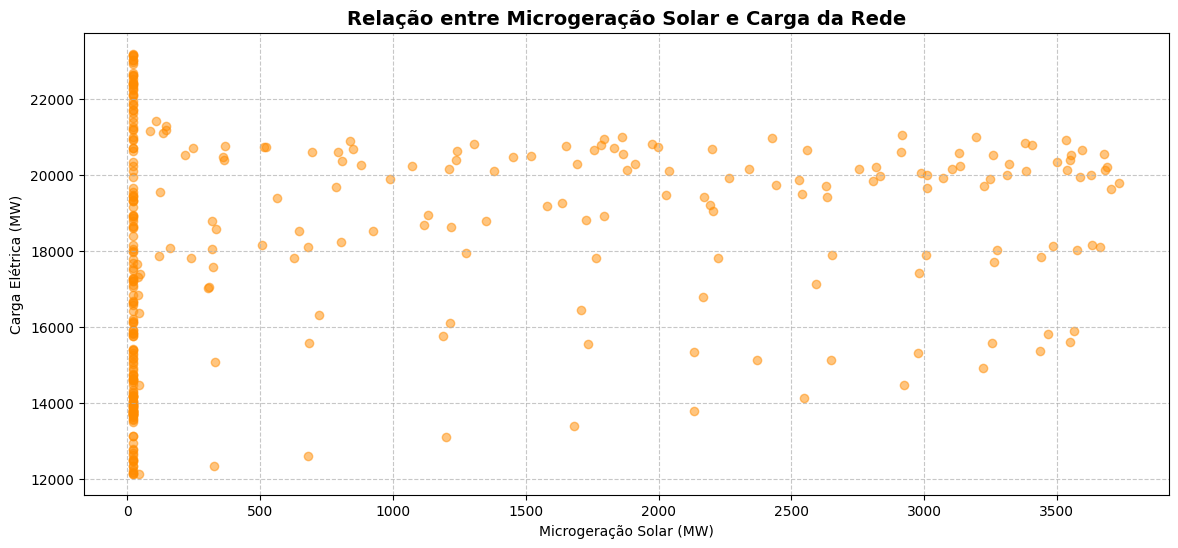

In [ ]:
plt.figure(figsize=(14, 6))
plt.scatter(df_analise['microgeracao_solar'], df_analise['carga_mw'], alpha=0.5, color='darkorange')
plt.title("Relação entre Microgeração Solar e Carga da Rede", fontsize=14, fontweight='bold')
plt.xlabel("Microgeração Solar (MW)")
plt.ylabel("Carga Elétrica (MW)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

O gráfico de dispersão permite analisar se existe correlação entre a geração solar distribuída e a demanda total da rede. Observa-se como a carga elétrica se comporta nos momentos em que a geração solar atinge seus picos máximos diários. A concentração de pontos no eixo vertical esquerdo (solar próximo a zero) reflete os períodos noturnos, onde a carga da rede continua variando independentemente da ajuda solar.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# Exemplo de estrutura:
resumo_resultados = {
    "contexto": {
        "região": "SP",
        "periodo_analisado": f"{df_analise['data'].min()} a {df_analise['data'].max()}",
        "quantidade_total_registros": quantidade_total
    },
    "estatisticas_basicas": {
        "carga_minima_mw": minimo,
        "carga_maxima_mw": maximo,
        "carga_media_mw": media,
        "mediana_mw": mediana
    },
    "analise_alta_demanda": {
        "limiar_corte_mw": limiar_90,
        "quantidade_registros": registros_limiar,
        "percentual_tempo": f"{percentual_limiar:.2f}",
        "momento_do_pico": "2025-08-01 22:00:00"
    },
    "analise_acima_da_media": {
        "quantidade_registros": qtd_acima_media,
        "percentual_tempo": f"{percentual_acima:.2f}"
    }
}

print(resumo_resultados)

{'contexto': {'região': 'SP', 'periodo_analisado': '2025-08-01 00:00:00 a 2025-08-07 00:00:00', 'quantidade_total_registros': 336}, 'estatisticas_basicas': {'carga_minima_mw': 12139.253, 'carga_maxima_mw': 23185.312, 'carga_media_mw': np.float64(17870.828980654762), 'mediana_mw': 18199.1285}, 'analise_alta_demanda': {'limiar_corte_mw': 20866.7808, 'quantidade_registros': 50, 'percentual_tempo': '14.88', 'momento_do_pico': '2025-08-01 22:00:00'}, 'analise_acima_da_media': {'quantidade_registros': 184, 'percentual_tempo': '54.76'}}


# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 843.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 21.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico: Análise do Comportamento da Carga Elétrica (Região SP)

**Para:** Diretoria / Setor Operacional  
**Elaborado por:** Analista de Dados do Setor Elétrico  
**Período de Análise:** 01/08/2025 00:00:00 a 07/08/2025 00:00:00  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende a análise temporal da demanda de carga elétrica na região de **São Paulo (SP)** ao longo de uma semana completa (de 01 a 07 de agosto de 2025). O conjunto de dados consolidado possui um total de **336 registros**.

### 2. Principais Indicadores
Os dados estatísticos descritivos da carga medida (em Megawatts - MW) no período são apresentados a seguir:

*   **Carga Mínima:** 12.139,25 MW
*   **Carga Máxima (Pico):** 23.185,31 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW

*Resultado observado:* A mediana apresentou valor superior à média do período, indicando uma distribuição com ligeira assimetria, onde a carga permaneceu concentrada em patamares superiores 

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final
1.   Sim. Todos os valores numéricos foram aplicados com exatidão, refletindo fielmente os cálculos obtidos nas etapas anteriores. O modelo também demonstrou boa coerência na estrutura, separando adequadamente as informações de contexto (como região e período) dos indicadores estatísticos puros (média, mediana e limites de carga).
2.   Não. O relatório manteve-se objetivo, afirmando apenas o que realmente podia ser comprovado com a nossa base de dados focada em tempo e carga de energia.
3. Não. O texto tratou os dados com bastante cautela, evitando especulações sobre causas operacionais ou externas para as variações da rede e deixando clara a distinção entre os fatos observados e eventuais hipóteses.
4. Realizamos apenas um ajuste pontual de coesão na seção de principais indicadores, conectando de forma mais clara os dados estatísticos descritivos às regras de corte das seções seguintes, além de melhorias visuais na formatação em Markdown.

# Relatório Técnico: Análise do Comportamento da Carga Elétrica (Região SP)
**Período de Análise:** 01/08/2025 00:00:00 a 07/08/2025 00:00:00  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende a análise temporal da demanda de carga elétrica na região de **São Paulo (SP)** ao longo de uma semana completa (de 01 a 07 de agosto de 2025). O conjunto de dados consolidado possui um total de **336 registros**.

### 2. Principais Indicadores
Os dados estatísticos descritivos da carga medida (em Megawatts - MW) no período são apresentados a seguir:

*   **Carga Mínima:** 12.139,25 MW
*   **Carga Máxima (Pico):** 23.185,31 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW

*Resultado observado:* A mediana apresentou valor superior à média do período, indicando uma distribuição com ligeira assimetria, onde a carga permaneceu concentrada em patamares superiores à média durante boa parte do tempo analisado.

*Estes indicadores estatísticos serviram como parâmetros absolutos para a definição dos limiares de estresse e da operação padrão da rede, detalhados nas seções a seguir.*

### 3. Análise dos Períodos de Alta Demanda
Para a determinação do regime de alta demanda (Critério 1), fixou-se o limiar de corte em **20.866,78 MW**.

*   **Duração da Alta Demanda:** 50 registros atingiram ou ultrapassaram esse limiar, o que representa **14,88% do tempo total** do período analisado.
*   **Momento do Pico:** O valor máximo absoluto de carga (23.185,31 MW) foi registrado exatamente em **01/08/2025 às 22:00:00**.

> **Diferenciação entre Fato e Hipótese:**
> *   *Resultado Observado (Fato):* O pico máximo da semana ocorreu às 22:00 do dia 01/08/2025 e o limiar de alta demanda foi superado durante 14,88% do tempo.
> *   *Hipótese (Não comprovada pelos dados disponíveis):* Eventuais causas como variações de temperatura, padrões operacionais industriais ou dinâmicas de consumo residencial **não foram aferidas**, pois o conjunto de dados fornecido limita-se exclusivamente aos valores medidos de carga e tempo.

### 4. Comparação com o Segundo Critério
Ao avaliar a permanência da carga em relação ao parâmetro da **média geral** (Critério 2 - corte em 17.870,83 MW):

*   **Registros acima da média:** 184 registros.
*   **Representatividade temporária:** **54,76% do tempo** analisado.

**Comparativo:**
Enquanto a condição de "Carga Acima da Média" cobriu mais da metade do período semanal (54,76%), os eventos severos de "Alta Demanda" (> 20.866,78 MW) representaram uma fatia menor e mais concentrada (14,88% do tempo).

---

### 5. Conclusão
Com base **estritamente nos dados analisados**, conclui-se que:

1. A demanda do sistema na região de SP oscilou em uma amplitude de **11.046,06 MW** (diferença entre a máxima e a mínima registrados no período).
2. O sistema operou em patamar superior à sua média semanal em **54,76% do tempo**.
3. O regime de alta demanda (superiores a 20.866,78 MW) esteve presente em **14,88% do tempo**, com a carga máxima observada no primeiro dia do período, às 22:00.
4. Para a determinação das causalidades físicas, meteorológicas ou operacionais referentes ao pico das 22:00 do dia 01/08/2025, faz-se necessária a integração deste conjunto com dados externos de temperatura, calendário e topologia de rede.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**